In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("corporate_dataset.csv")
df.head()

,company_id,industry,country,year,ai_adoption_level,ai_investment_usd,automation_rate,cost_savings,revenue_impact,productivity_gain,employee_ai_training_hours,ai_maturity_score,deployment_count
0,CORP-06613,Financial Services,China,2029,0.4987,11747237,0.4119,3519354,2751513,0.3924,76.8,6.37,29
1,CORP-01597,Agriculture,Germany,2032,0.5213,1267219,0.4580,295244,304776,0.4639,83.2,7.19,37
2,CORP-02938,Energy,United States,2024,0.6147,8168951,0.5821,2472329,5170304,0.4953,123.1,6.72,26
3,CORP-05207,Retail,Germany,2021,0.4401,1234261,0.2880,512061,-233448,0.3078,63.1,5.68,21
4,CORP-07489,Technology,United States,2024,0.1918,5000645,0.1906,2122064,2110644,0.1910,29.6,4.33,16


In [3]:
df["roi_score"] = (
    (df["revenue_impact"] + df["cost_savings"] - df["ai_investment_usd"])
    / df["ai_investment_usd"]
)

df["investment_efficiency"] = (
    df["revenue_impact"] / df["ai_investment_usd"]
)
df["productivity_index"] = (
    df["productivity_gain"] * df["automation_rate"]
)
df["ai_effectiveness_score"] = (
    df["ai_maturity_score"]
    * df["ai_adoption_level"]
    * df["automation_rate"]
)
df["revenue_per_ai_dollar"] = (
    df["revenue_impact"]
    / df["ai_investment_usd"]
)
df["business_impact_score"] = (
    df["revenue_impact"]
    + df["cost_savings"]
)
df.head()

,company_id,industry,country,year,ai_adoption_level,ai_investment_usd,automation_rate,cost_savings,revenue_impact,productivity_gain,employee_ai_training_hours,ai_maturity_score,deployment_count,roi_score,investment_efficiency,productivity_index,ai_effectiveness_score,revenue_per_ai_dollar,business_impact_score
0,CORP-06613,Financial Services,China,2029,0.4987,11747237,0.4119,3519354,2751513,0.3924,76.8,6.37,29,-0.466184,0.234226,0.161630,1.308491,0.234226,6270867
1,CORP-01597,Agriculture,Germany,2032,0.5213,1267219,0.4580,295244,304776,0.4639,83.2,7.19,37,-0.526506,0.240508,0.212466,1.716651,0.240508,600020
2,CORP-02938,Energy,United States,2024,0.6147,8168951,0.5821,2472329,5170304,0.4953,123.1,6.72,26,-0.064429,0.632921,0.288314,2.404529,0.632921,7642633
3,CORP-05207,Retail,Germany,2021,0.4401,1234261,0.2880,512061,-233448,0.3078,63.1,5.68,21,-0.774267,-0.189140,0.088646,0.719933,-0.189140,278613
4,CORP-07489,Technology,United States,2024,0.1918,5000645,0.1906,2122064,2110644,0.1910,29.6,4.33,16,-0.153568,0.422074,0.036405,0.158292,0.422074,4232708


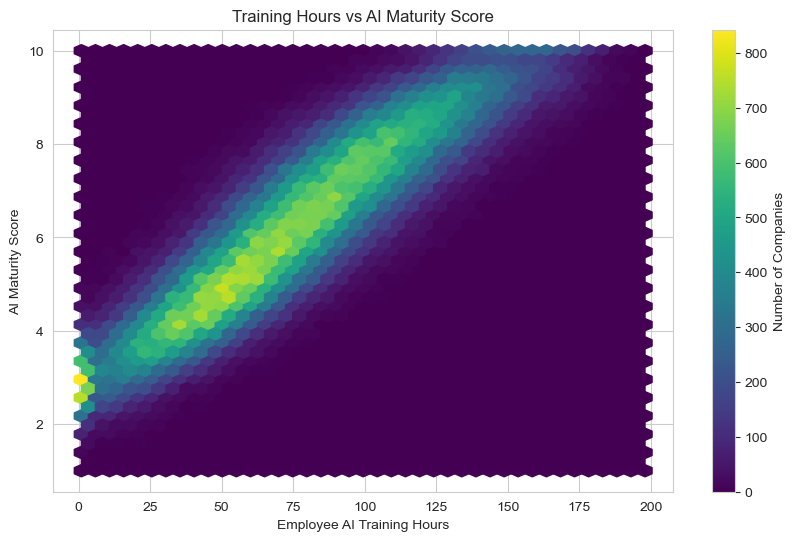

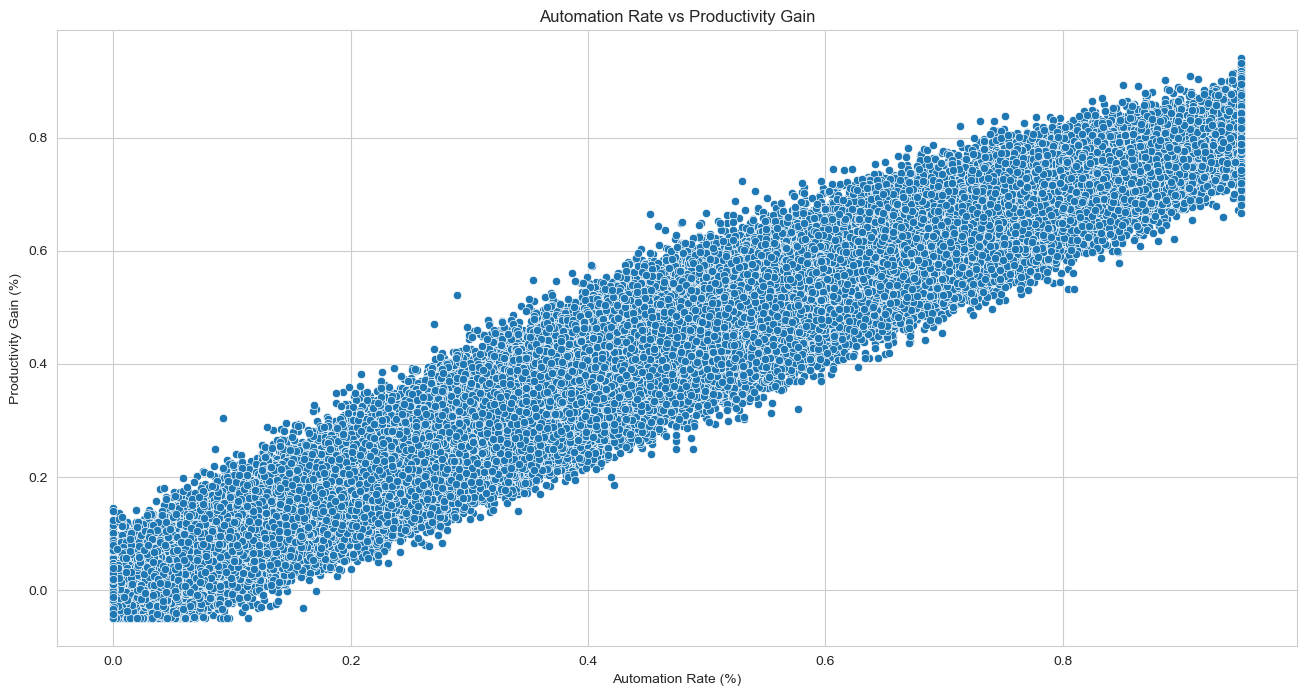

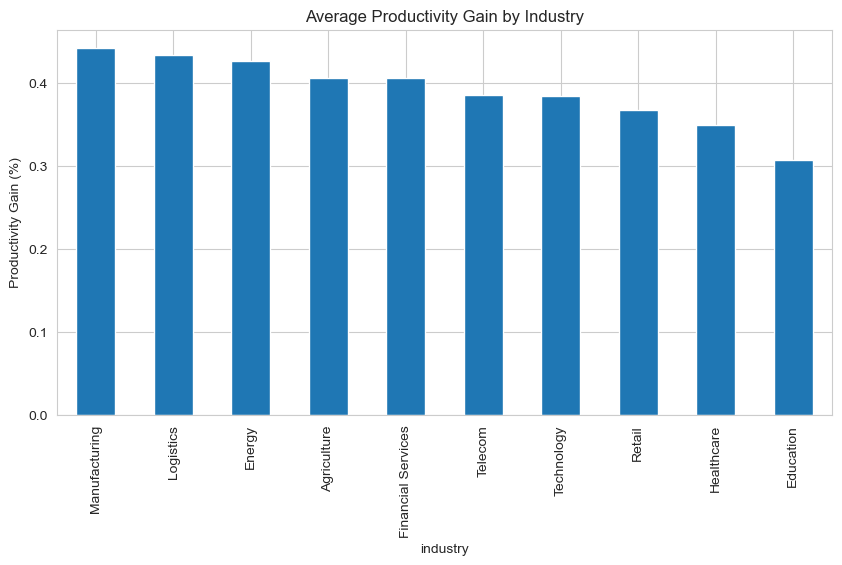

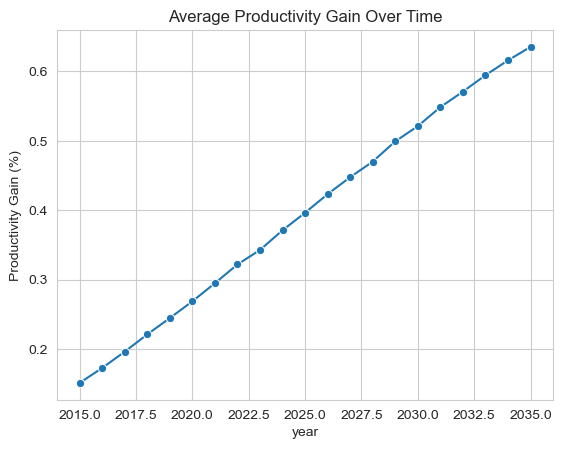

<Axes: xlabel='year', ylabel='productivity_gain'>

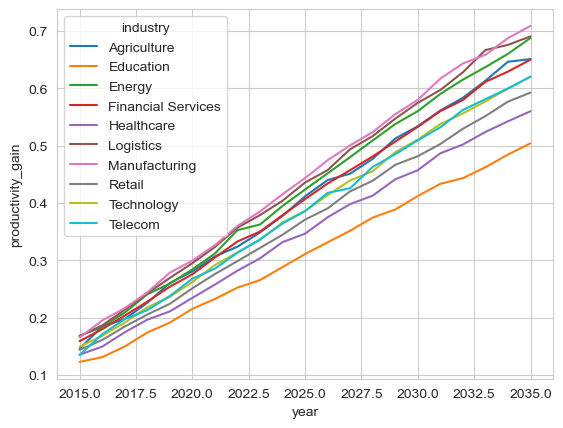

In [13]:
#Visualizations
#Training Hours vs AI Maturity Score
#Analyze workforce readiness and skill development.
#by hexbin plot
plt.figure(figsize=(10,6))

plt.hexbin(
    df["employee_ai_training_hours"],
    df["ai_maturity_score"],
    gridsize=40,
    cmap="viridis"
)

plt.colorbar(label="Number of Companies")

plt.xlabel("Employee AI Training Hours")
plt.ylabel("AI Maturity Score")
plt.title("Training Hours vs AI Maturity Score")

plt.show()

#Automation Rate vs Productivity Gain
#Measure operational efficiency improvements.

plt.figure(figsize=(16,8))
sns.scatterplot(
    data=df,
    x="automation_rate",
    y="productivity_gain"
)

plt.title("Automation Rate vs Productivity Gain")
plt.xlabel("Automation Rate (%)")
plt.ylabel("Productivity Gain (%)")
plt.show()


#Employee Satisfaction vs AI Adoption
#Understand workforce sentiment during AI transformation.

# df["workforce_readiness_score"] = (
#     0.5 * (df["employee_ai_training_hours"] / df["employee_ai_training_hours"].max()) +
#     0.5 * (df["ai_maturity_score"] / df["ai_maturity_score"].max())
# ) * 10

# plt.figure(figsize=(10,6))

# sns.boxplot(
#     data=df,
#     x="ai_adoption_level",
#     y="workforce_readiness_score"
# )

# plt.title("Workforce Readiness Across AI Adoption Levels")
# plt.xlabel("AI Adoption Level")
# plt.ylabel("Workforce Readiness Score")

# plt.grid(axis="y", alpha=0.3)
# plt.show()


 #Productivity Trends Dashboard
#Track productivity improvements across industries.

#1.Industry-wise Productivity Gain
industry_prod = (
    df.groupby("industry")["productivity_gain"]
      .mean()
      .sort_values(ascending=False)
)

industry_prod.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Productivity Gain by Industry")
plt.ylabel("Productivity Gain (%)")
plt.show()

#2.Productivity Trend Over Time

year_prod = (
    df.groupby("year")["productivity_gain"]
      .mean()
      .reset_index()
)

sns.lineplot(
    data=year_prod,
    x="year",
    y="productivity_gain",
    marker="o"
)

plt.title("Average Productivity Gain Over Time")
plt.ylabel("Productivity Gain (%)")

plt.show()

#3.

industry_year = (
    df.groupby(["year","industry"])
      ["productivity_gain"]
      .mean()
      .reset_index()
)

sns.lineplot(
    data=industry_year,
    x="year",
    y="productivity_gain",
    hue="industry"
)


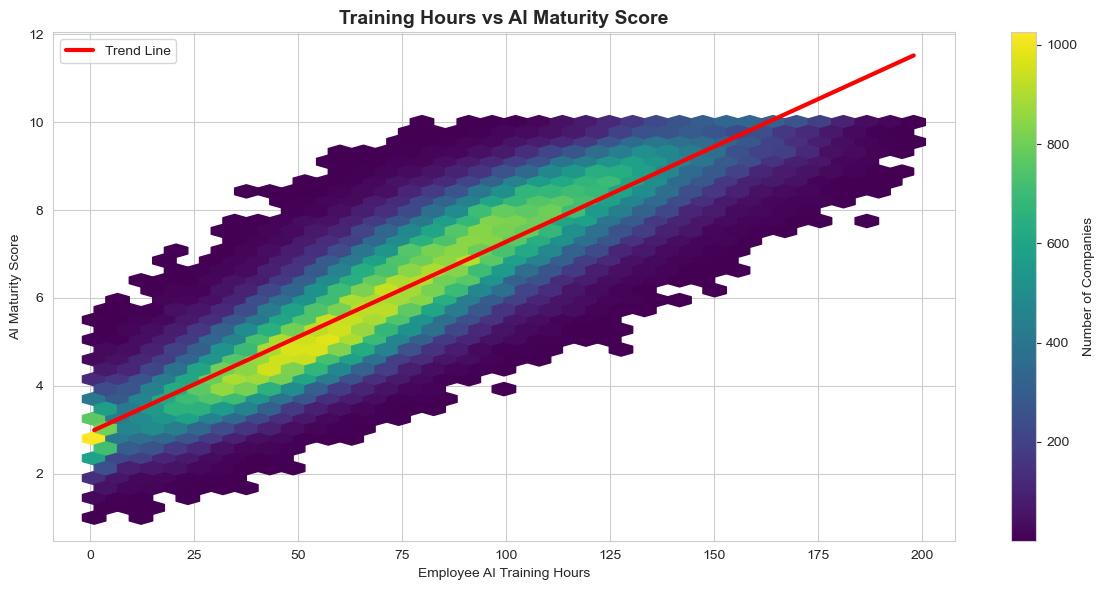

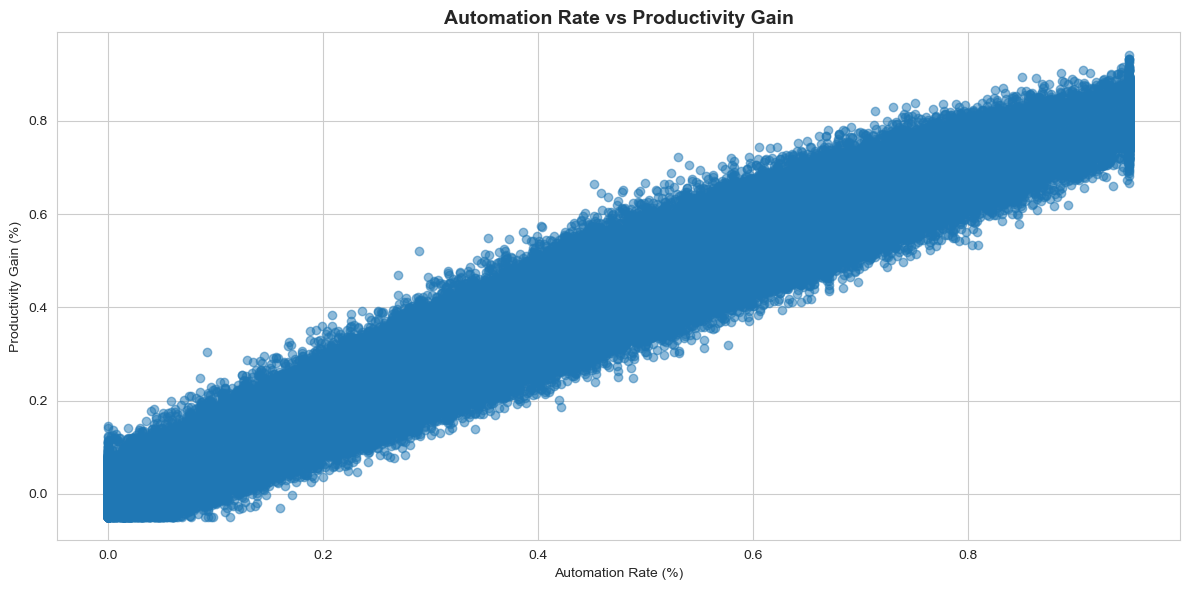

In [ ]:
# ==========================================================
# AI ADOPTION & PRODUCTIVITY ANALYTICS DASHBOARD
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

# Workforce Readiness Score
df["workforce_readiness_score"] = (
    0.5 * (df["employee_ai_training_hours"] / df["employee_ai_training_hours"].max()) +
    0.5 * (df["ai_maturity_score"] / df["ai_maturity_score"].max())
) * 10

# Employee Satisfaction Score (derived metric)
df["employee_satisfaction_score"] = (
    0.4 * df["productivity_gain"] +
    0.3 * (df["employee_ai_training_hours"] / df["employee_ai_training_hours"].max()) * 100 +
    0.3 * df["ai_maturity_score"]
)

# ==========================================================
# 1. TRAINING HOURS VS AI MATURITY SCORE
# ==========================================================

plt.figure(figsize=(12,6))

hb = plt.hexbin(
    df["employee_ai_training_hours"],
    df["ai_maturity_score"],
    gridsize=35,
    cmap="viridis",
    mincnt=1
)

plt.colorbar(hb, label="Number of Companies")

# Trend Line
z = np.polyfit(
    df["employee_ai_training_hours"],
    df["ai_maturity_score"],
    1
)

p = np.poly1d(z)

x_sorted = np.sort(df["employee_ai_training_hours"])

plt.plot(
    x_sorted,
    p(x_sorted),
    color="red",
    linewidth=3,
    label="Trend Line"
)

plt.title(
    "Training Hours vs AI Maturity Score",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Employee AI Training Hours")
plt.ylabel("AI Maturity Score")
plt.legend()

plt.tight_layout()
plt.show()

# ==========================================================
# 2. AUTOMATION RATE VS PRODUCTIVITY GAIN
# ==========================================================

plt.figure(figsize=(12,6))

sns.regplot(
    data=df,
    x="automation_rate",
    y="productivity_gain",
    scatter_kws={"alpha":0.5},
    line_kws={"linewidth":3}
)

plt.title(
    "Automation Rate vs Productivity Gain",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Automation Rate (%)")
plt.ylabel("Productivity Gain (%)")

plt.tight_layout()
plt.show()

# ==========================================================
# 3. EMPLOYEE SATISFACTION VS AI ADOPTION
# ==========================================================

plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x="ai_adoption_level",
    y="employee_satisfaction_score"
)

plt.title(
    "Employee Satisfaction Across AI Adoption Levels",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("AI Adoption Level")
plt.ylabel("Employee Satisfaction Score")

plt.tight_layout()
plt.show()

# ==========================================================
# 4. PRODUCTIVITY TRENDS DASHBOARD
# ==========================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18,10)
)

fig.suptitle(
    "Productivity Trends Dashboard",
    fontsize=18,
    fontweight="bold"
)

# ----------------------------------------------------------
# Chart 1: Industry-wise Productivity Gain
# ----------------------------------------------------------

industry_prod = (
    df.groupby("industry")["productivity_gain"]
      .mean()
      .sort_values(ascending=False)
)

industry_prod.plot(
    kind="bar",
    ax=axes[0,0]
)

axes[0,0].set_title("Average Productivity Gain by Industry")
axes[0,0].set_ylabel("Productivity Gain (%)")
axes[0,0].tick_params(axis="x", rotation=45)

# ----------------------------------------------------------
# Chart 2: Productivity Trend Over Time
# ----------------------------------------------------------

year_prod = (
    df.groupby("year")["productivity_gain"]
      .mean()
      .reset_index()
)

sns.lineplot(
    data=year_prod,
    x="year",
    y="productivity_gain",
    marker="o",
    linewidth=3,
    ax=axes[0,1]
)

axes[0,1].set_title("Average Productivity Gain Over Time")
axes[0,1].set_ylabel("Productivity Gain (%)")

# ----------------------------------------------------------
# Chart 3: Industry Productivity Trends
# ----------------------------------------------------------

industry_year = (
    df.groupby(["year","industry"])
      ["productivity_gain"]
      .mean()
      .reset_index()
)

sns.lineplot(
    data=industry_year,
    x="year",
    y="productivity_gain",
    hue="industry",
    marker="o",
    ax=axes[1,0]
)

axes[1,0].set_title("Industry Productivity Trends")

# ----------------------------------------------------------
# Chart 4: Productivity Distribution
# ----------------------------------------------------------

sns.histplot(
    data=df,
    x="productivity_gain",
    bins=20,
    kde=True,
    ax=axes[1,1]
)

axes[1,1].set_title("Distribution of Productivity Gains")
axes[1,1].set_xlabel("Productivity Gain (%)")

plt.tight_layout()
plt.show()

# ==========================================================
# OPTIONAL KPI SUMMARY
# ==========================================================

print("="*50)
print("AI ADOPTION ANALYTICS SUMMARY")
print("="*50)

print(
    f"Average Productivity Gain: "
    f"{df['productivity_gain'].mean():.2f}%"
)

print(
    f"Average AI Maturity Score: "
    f"{df['ai_maturity_score'].mean():.2f}"
)

print(
    f"Average Automation Rate: "
    f"{df['automation_rate'].mean():.2f}%"
)

print(
    f"Average Training Hours: "
    f"{df['employee_ai_training_hours'].mean():.2f}"
)

print(
    f"Top Performing Industry: "
    f"{industry_prod.idxmax()}"
)